# Importing necessary packages

In [36]:
!pip install tensorflow matplotlib seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Loading the dataset

In [2]:
sdir = '/content/drive/MyDrive/Face_emotion_data'
data = {'filepaths': [], 'labels': []}

for dataset in ['train', 'test']:
    setpath = os.path.join(sdir, dataset)
    classlist = os.listdir(setpath)
    for klass in classlist:
        classpath = os.path.join(setpath, klass)
        for file in os.listdir(classpath):
            fpath = os.path.join(classpath, file)
            data['filepaths'].append(fpath)
            data['labels'].append(klass)

df = pd.DataFrame(data)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6694 entries, 0 to 6693
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   filepaths  6694 non-null   object
 1   labels     6694 non-null   object
dtypes: object(2)
memory usage: 104.7+ KB


# Showing image count per class

In [42]:
print("\n Number of Images per Class:")
print(df['labels'].value_counts())


 Number of Images per Class:
labels
happiness    2430
anger        1761
sadness      1699
neutral       804
Name: count, dtype: int64


# Spliting data into training, validation, and test sets

In [43]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['labels'], random_state=123)
train_df, valid_df = train_test_split(train_df, test_size=0.1, stratify=train_df['labels'], random_state=123)

Classes: ['anger', 'happiness', 'neutral', 'sadness']


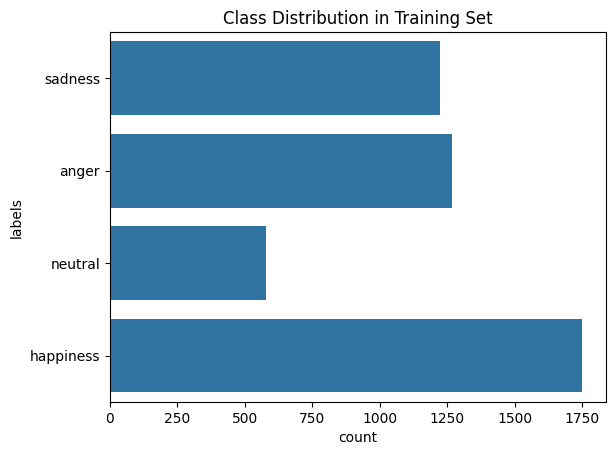

In [40]:
# Classes and counts
classes = sorted(train_df['labels'].unique())
print(f"Classes: {classes}")
sns.countplot(y=train_df['labels'])
plt.title("Class Distribution in Training Set")
plt.show()

#  IMAGE PREPROCESSING

In [27]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_test_datagen = ImageDataGenerator(rescale=1./255)

# Loading Data
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

valid_gen = valid_test_datagen.flow_from_dataframe(
    valid_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

test_gen = valid_test_datagen.flow_from_dataframe(
    test_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 4819 validated image filenames belonging to 4 classes.
Found 536 validated image filenames belonging to 4 classes.
Found 1339 validated image filenames belonging to 4 classes.


# MODEL BUILDING

In [28]:
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
845
# MODEL TRAINING
EPOCHS = 15
history = model.fit(train_gen, validation_data=valid_gen, epochs=EPOCHS, callbacks=[early_stopping, lr_scheduler])

# MODEL EVALUATION
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n Test Accuracy: {test_acc * 100:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.3152 - loss: 2.0293 - val_accuracy: 0.3022 - val_loss: 1.6910 - learning_rate: 5.0000e-05
Epoch 2/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.4986 - loss: 1.3753 - val_accuracy: 0.5131 - val_loss: 1.3153 - learning_rate: 5.0000e-05
Epoch 3/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.5518 - loss: 1.2156 - val_accuracy: 0.6045 - val_loss: 1.1694 - learning_rate: 5.0000e-05
Epoch 4/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.6007 - loss: 1.1211 - val_accuracy: 0.6418 - val_loss: 1.0787 - learning_rate: 5.0000e-05
Epoch 5/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.6556 - loss: 0.9394 - val_accuracy: 0.6511 - val_loss: 1.0925 - learning_rate: 5.0000e-05
Epoch 6/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.6561 - loss: 0.9137 - val_accuracy: 0.7127 - val_loss: 0.8394 - learning_rate: 5.0000e-05
Epoch 7/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - acc

# CLASSIFICATION REPORT

In [29]:
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

print("\n🔹 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 451ms/step

🔹 Classification Report:

              precision    recall  f1-score   support

       anger       0.80      0.83      0.82       352
   happiness       0.92      0.92      0.92       486
     neutral       0.61      0.79      0.69       161
     sadness       0.81      0.68      0.74       340

    accuracy                           0.82      1339
   macro avg       0.79      0.80      0.79      1339
weighted avg       0.83      0.82      0.82      1339



# -------------------- CONFUSION MATRIX -------------------- #

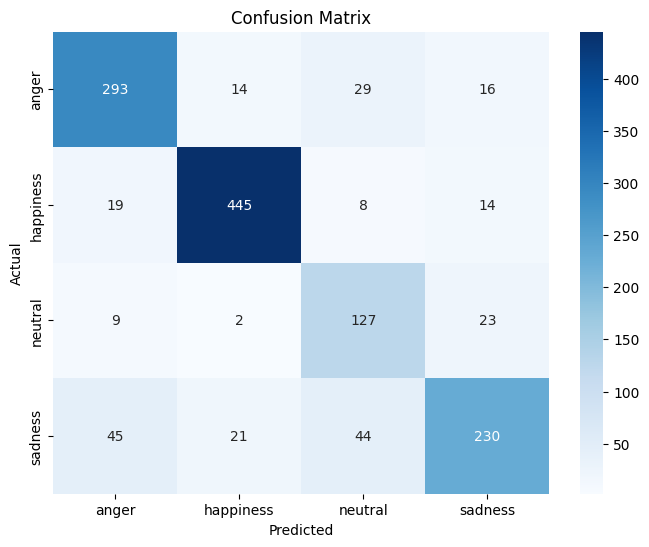

In [30]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

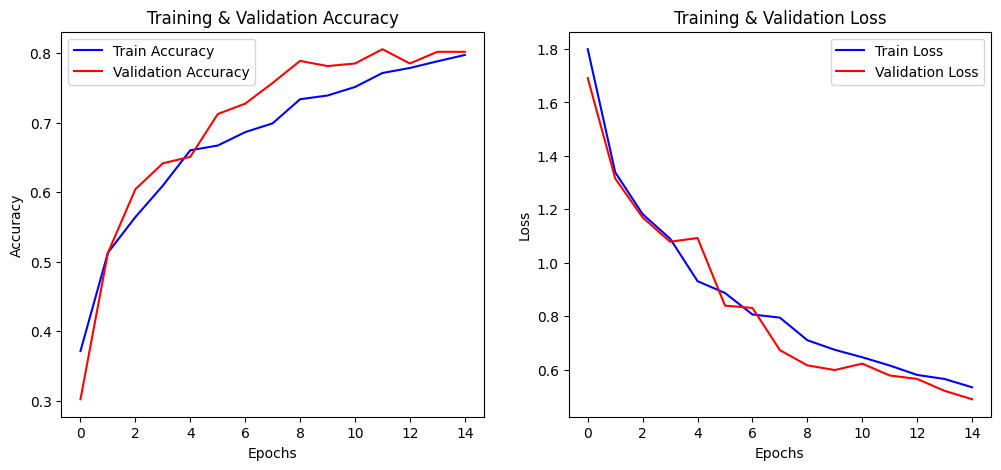

In [31]:
# Accuracy Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()


# Saving the model

In [34]:
model.save('facial_emotion_model.h5')

# Function to upload an image and predict emotion

In [47]:
def predict_uploaded_image():
    try:
        uploaded = files.upload()

        for filename in uploaded.keys():
            # Loading and preprocess the image
            img = load_img(filename, target_size=IMG_SIZE)
            img_array = img_to_array(img) / 255.0  # Normalize
            img_array = np.expand_dims(img_array, axis=0)  # Reshape for model

            # Predict using the trained model
            prediction = model.predict(img_array)
            predicted_class = classes[np.argmax(prediction)]
            confidence = np.max(prediction) * 100  # Get confidence score

            plt.imshow(img)
            plt.title(f"Predicted Emotion: {predicted_class}\nConfidence: {confidence:.2f}%")
            plt.axis("off")
            plt.show()

    except Exception as e:
        print("Error:", e)
        print("Please upload a valid image file.")



Saving anger1.jpg to anger1 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


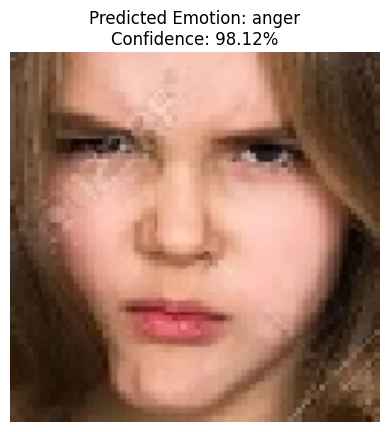

In [45]:
predict_uploaded_image()
